# Tutorial 2: The cortical rate-scale representation with aud2cor
 
The mammalian auditory system starts its sound analysis in the cochlea by extracting time-varying frequency information from incoming sound waves (see `wav2aud`). Thereafter, subcortical nuclei and the primary auditory cortex extract regularities in the spectral and temporal variations obtained from the cochlea (`aud2cor`). The function `aud2cor` aims to mimic this process using modulation transfer functions calibrated on physiological data from the ferret brain. [[1](#References)]
 
While `aud2cor` could perform a 2-dimensional convolution with two physiologically tuned filter banks in the time-frequency domain, it implements these computations in the 2D modulation frequency domain where convolution simplifies to element-wise multiplication. This significantly enhances computational efficiency and filter design flexibility. The algorithm works as follows:
 
- **Input Representation**: The input to `aud2cor` is an auditory spectrogram (audiogram) representing energy across time and frequency, modeled after mammalian/ferret auditory processing. It is a real-valued matrix of shape [$N, M$], where $N$ is the number of time points and $M$ is the number of frequency channels.
 
- **Zero-Padding**: The dimensions of the audiogram are padded to the next highest power of 2, yielding a shape of [$N_{pad}, M_{pad}$], where $N_{pad}$ is the padded time axis and $M_{pad}$ is the padded frequency axis. This optimizes Fast Fourier Transform (FFT) efficiency. Next, the time axis is zero-padded by an additional factor of 2, yielding a shape of [$2 \cdot N_{pad}, M_{pad}$]. This extra space prevents circular convolution aliasing along the temporal axis when filtering and transforming back. It is applied only along the time axis because here, positive and negative temporal rates will be explicitly separated into distinct directional channels, whereas along the frequency axis, only the positive spectral scales are retained in memory.
 
- **2D Fast Fourier Transform**: A 2D FFT is applied to the padded spectrogram—first along the frequency axis, and then along the time axis. This maps the time-frequency domain into the 2D modulation frequency domain ($\omega, \Omega$), capturing temporal rates $\omega$ (vertical pattern changes over time, in Hz) and spectral scales $\Omega$ (horizontal pattern changes across frequency, in cycles/octave). The resulting 2D modulation spectrum has shape [$2 \cdot N_{pad}, M_{pad}$], representing the frequencies at which temporal and spectral regularities occur (i.e., how narrow or wide the spectrotemporal ripples are). Only the positive spectral frequencies are stored, which implicitly drops Hermitian conjugate symmetry.
 
- **Cortical Filter Bank Application**: To mirror spectrotemporal modulation sensitivities in the early auditory system of mammals, the 2D modulation spectrum is filtered using two banks of transfer functions calibrated to match recordings of the ferret primary auditory cortex:
    - **Temporal Filters (`HR`)**: Provided by `gen_cort`, which produces a complex-value transfer function. These bandpass filters isolate specific temporal rates (Hz).
    - **Spectral Filters (`HS`)**: Generated by `gen_corf`, which produces a real-valued transfer function. These bandpass filters isolate specific spectral scales (cycles/octave). 
 
  Multiplying the 2D modulation spectrum by all combinations of scales and signed (positive/negative) rates yields $K_2 \times (K_1 \cdot 2)$ filtered 2D matrices. This multiplication is done in the modulation-frequency domain and is equivalent to a convolution in the equivalent temporal domain, but is computationally much cheaper.
 
- **Inverse 2D FFT and Separable Processing**: Because the spectrotemporal filters are mathematically separable, the inverse 2D FFT (IFFT) is applied sequentially:
    1. The spectrum is multiplied by the temporal filters `HR`. This is done separately for positive and negative rate filters (downward vs. upward sweeps), which now also breaks Hermitian symmetry along the temporal axis. The result is transformed via a 1D IFFT along time to produce a complex-valued analytic signal, which is then cropped from $2 \cdot N_{pad}$ back down to $N + 2 \cdot dN$ time-frames, where $dN = \left \lfloor{\frac{N}{2} \times \textrm{temporal margin}}\right \rfloor$ is a left and right padding chosen by the user via the `temporal_margin` argument (see below).
    2. The intermediate output is multiplied by the spectral filters `HS` and transformed via a 1D IFFT along the frequency axis. Because negative spectral frequencies were zeroed out previously, this step also yields complex-valued analytic signals. The output is cropped back down to $M + 2 \cdot dM$ frequency channels, where $dM = \left \lfloor{\frac{M}{2} \times \textrm{spectral margin}}\right \rfloor$ is a left and right padding chosen by the user via the `spectral_margin` argument (see below).
 
- **Output Representation**: The final output is the cortical representation (`cr`), a 4D complex-valued tensor of shape [$num\_scales, num\_rates \cdot 2, N + 2 \cdot dN, M + 2 \cdot dM$]. This restores the original time-frequency coordinates while decomposing every bin into its underlying scale, rate, and directional sweep modulation channels.

**Interpreting the output of `aud2cor`:**
Each channel of `cr` comes from one temporal filter (`HR`, from `gen_cort`) paired with one spectral filter (`HS`, from `gen_corf`).
Although gen_cort returns a complex transfer function and gen_corf returns a real one, `cr` is still complex-valued regardless. That's because aud2cor breaks Hermitian symmetry along both axes: it splits positive and negative rates into separate directional channels (time), and keeps only positive scales (frequency). Both IFFTs therefore return complex analytic signals rather than real values.

So every (scale, rate, time, freq) bin has a magnitude and a phase:

- |cr| = how strongly a ripple at that rate and scale is present at that time-frequency location.
- angle(cr) = the instantaneous phase of the analytic signal at that time-frequency location.

For example, if a ripple at a particular pair (rate, scale) is a sinusoid $A * cos(2πft + φ)$, then angle(cr) is the phase $φ$

Two bins with equal magnitude but different phase carry the same modulation strength; they differ only in where the ripple's peaks and troughs sit relative to that location (ie, for a given time and frequency pair).

## **Using aud2cor**

This tutorial loads an audio file from one of the examples and creates an audiogram, as in Tutorial 1, which is then passed to `aud2cor` as the input `audiogram`. The resulting cortical representation is referred to as a **corticogram**. 

Then there are several optional parameters that can be passed:

(audiogram: np.ndarray, 
            frame_length: int=4,
            temporal_margin: float=0, # fullness of temporal margin
            spectral_margin: float=0, # fullness of spectral margin
            bandpass: int=1,
            rates: np.ndarray=None,
            scales: np.ndarray=None,
            channels_per_oct: int=None)
- **`frame_length`, int**: The same frame length parameter as in `wav2aud`, 4 by default.
- **`temporal_margin`, float in [0, 1]**: Controls how much temporal margin (padding) is added around time axis of the corticogram. 0 by default.
- **`spectral_margin`, float in [0, 1]**: Controls how much spectral margin (padding) is added around the frequency axis of the corticogram. 0 by default.
- **`bandpass`, int**: Determines whether all filters should be bandpass. 1 by default.
- **`rates`, np.ndarray**: Defines the rates around which the temporal filters are tuned, in Hz. `2 ** np.linspace(np.log2(0.5), np.log2(128), 32)` by default.
- **`scales`, np.ndarray**: Defines the scales around which the spectral filters are tuned, in cycles per octave. `2 ** np.linspace(np.log2(1/5), np.log2(10), 32)` by default.
- **`channels_per_oct`, int**: Frequency resolution of the auditory spectrogram, in channels per octave. If using the default filterbank, this should be left empty. `None` by default.

> **Quickstart tips:** For most exploratory work, the defaults are a good place to start. Adding temporal or spectral margins will increase the computation time and use is discouraged unless necessary for your use case (for example, reconstruction). To reduce computation time and memory usage, rate and scale resolution can be changed by passing in arrays with fewer steps; for example, 16 instead of 32, as seen in `half_rates` and `half_scales` below. This is highly recommended for testing.

> **Warning:** Running this notebook from scratch can be memory-intensive and the kernel may crash. In this case, try closing other programs such as your browser and retry. It is also important to note that saving a corticogram with default parameters is expected to take about 1.5MB of disk space or more.

In [1]:
# setup
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import soundfile as soundf
import ipywidgets as widgets
from IPython.display import display, Audio

from neural_audio.examples.sounds.load import load_sound_file_paths
from neural_audio.wav2aud import wav2aud
from neural_audio.aud2cor import aud2cor, gen_cort, gen_corf
from neural_audio.utils.visualize_outputs import (
    plot_spectrogram,
    plot_cr_projection,
    plot_cr_temporal,
    plot_tempfilt_response,
    plot_spectfilt_response,
)

# Default (full-resolution) rate and scale vectors, matching aud2cor's internal defaults.
rates = 2 ** np.linspace(np.log2(0.5), np.log2(128), 32)   # temporal modulation rates [Hz]
scales = 2 ** np.linspace(np.log2(1/5), np.log2(10), 32)   # spectral modulation scales [cyc/oct]

### **Step 1: Generate audiogram**
Following the same steps as in Tutorial 1, an example sound can be selected using the dropdown menu and its audiogram generated using `wav2aud`.

In [2]:
# Get list of sound files. To get synthetic sounds, set synthetic=True, otherwise natural sounds will be used.
sound_files = load_sound_file_paths(synthetic=False)
sound_file_names = [Path(file).name for file in sound_files]

# Create dropwdown widget to select and play sound file
dropdown = widgets.Dropdown(options=sound_file_names, description='Sound file:')
audio_player = widgets.Output()
sound_file_path = sound_files[1]

def on_change(change):
    if change['type'] == 'change' and change['name'] == 'value':
        global sound_file_path
        for file in sound_files:
            if Path(file).name == change['new']: sound_file_path = file
        audio_player.clear_output()
        with audio_player:
            display(Audio(str(sound_file_path), autoplay=False))

dropdown.observe(on_change)
dropdown.value = sound_file_names[1]  # Set default value to the first sound file
display(dropdown, audio_player)

Dropdown(description='Sound file:', index=1, options=('cardboard tapping.wav', 'cardboard whirling.wav', 'gees…

Output()

Audiogram shape == [750 time points, 128 frequencies]


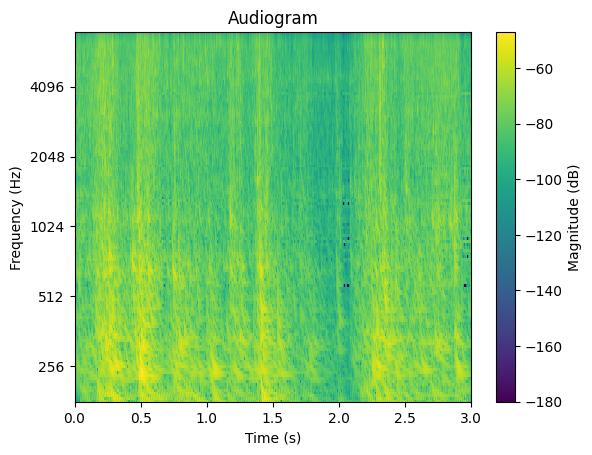

In [3]:
# Compute an audiogram with default parameters
waveform, sampling_rate = soundf.read(sound_file_path)
time_points_audiogram, frequencies_audiogram, audiogram  = wav2aud(waveform)

print(f"Audiogram shape == [{audiogram.shape[0]} time points, {audiogram.shape[1]} frequencies]")

# For convenience, visualize the output
plot_spectrogram(audiogram, time_points_audiogram, frequencies_audiogram, title='Audiogram')

### **Step 2: Generate cortical representation**
The audiogram from `wav2aud` is passed **directly** into `aud2cor` (no transpose needed), since both use the same (time, frequency) convention. Since default parameters were used for `wav2aud`, it is safe to also use the defaults for `aud2cor`. Note that **this step is far more computationally intensive and may take a few minutes**.

In [4]:
cr = aud2cor(audiogram)
print(f"Cortical representation shape: {cr.shape}")

num_scales, num_rate_channels, n_time, n_freq = cr.shape
print(f"Number of scales: {num_scales}")
print(f"Number of rate channels (rates x 2 directions): {num_rate_channels}")
print(f"Time frames: {n_time}")
print(f"Frequency frames: {n_freq}")

Cortical representation shape: (32, 64, 750, 128)
Number of scales: 32
Number of rate channels (rates x 2 directions): 64
Time frames: 750
Frequency frames: 128


### **Step 3: Visualization**
The output of `aud2cor` has four dimensions: scale, rate, time, and frequency. Because of this, it is useful to create 2D projections along specific axes. There are two functions under utils that aid visualization:

`plot_cr_projection` computes projections without temporal information. It takes the following inputs:
- `cr` - The cortical representation (output of aud2cor), an array [scale x rate x time x frequency]
- `rates` - The rate vector used to construct the cortical representation
- `scales` - The scale vector used to construct the cortical representation
- `frequencies`- The audiogram frequencies
The magnitude |cr| is averaged over the two sweep directions (since rate has two possible directions) and the time axis. Then, to compute the final projections, the third dimension is averaged to see how energy is distributed across the remaining two. For example, to compute the scale-rate visualization, frequency is averaged over. 

`plot_cr_temporal` is useful to visualize temporal changes. It takes the following inputs:
- `cr` - The cortical representation (output of aud2cor), an array [scale x rate x time x frequency]. Both sweep directions are expected by default and are averaged together, as in `plot_cr_projection`. To inspect a single direction, pass in the corresponding half, e.g. `cr[:, :len(rates)]`
- `rates` - The rate vector used to construct the cortical representation
- `scales` - The scale vector used to construct the cortical representation. If omitted, the axis shows the channel index instead
- `time_points` - The audiogram time points, in seconds. If omitted, the axis shows the frame index instead

Rather than averaging over the time axis, the function averages over the frequency axis and one additional axis. This gives two views: rate-time (averaged over scale and frequency) and scale-time (averaged over rate and frequency). Because the time axis is kept, this is the view to use for anything that varies over the course of the signal, such as onset and offset effects. 

(<Figure size 1200x400 with 6 Axes>,
 (<Axes: title={'center': 'Scale-Rate'}, xlabel='Rate [Hz]', ylabel='Scale [cyc/oct]'>,
  <Axes: title={'center': 'Scale-Frequency'}, xlabel='Frequency [Hz]', ylabel='Scale [cyc/oct]'>,
  <Axes: title={'center': 'Rate-Frequency'}, xlabel='Frequency [Hz]', ylabel='Rate [Hz]'>))

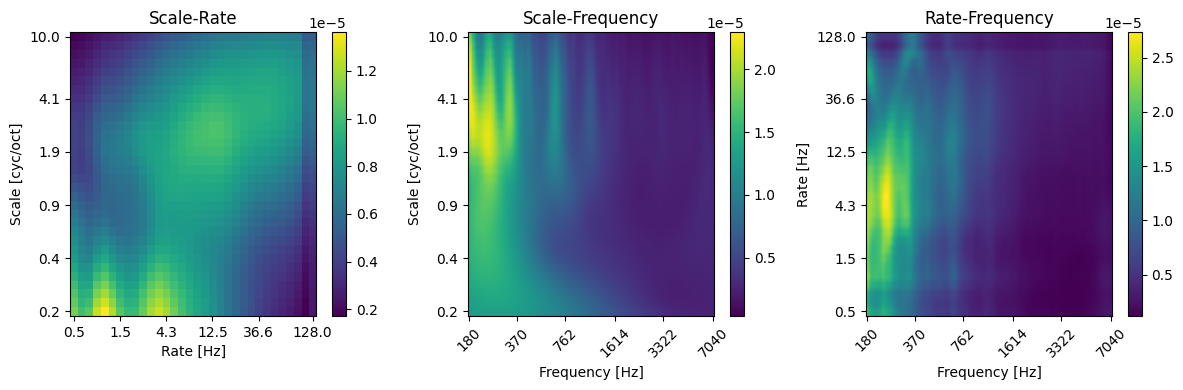

In [5]:
# time-averaged projections (temporal information lost)
plot_cr_projection(cr, rates, scales=scales, frequencies=frequencies_audiogram)

(<Figure size 1000x400 with 4 Axes>,
 (<Axes: title={'center': 'Rate-Time'}, xlabel='Time [s]', ylabel='Rate [Hz]'>,
  <Axes: title={'center': 'Scale-Time'}, xlabel='Time [s]', ylabel='Scale [cyc/oct]'>))

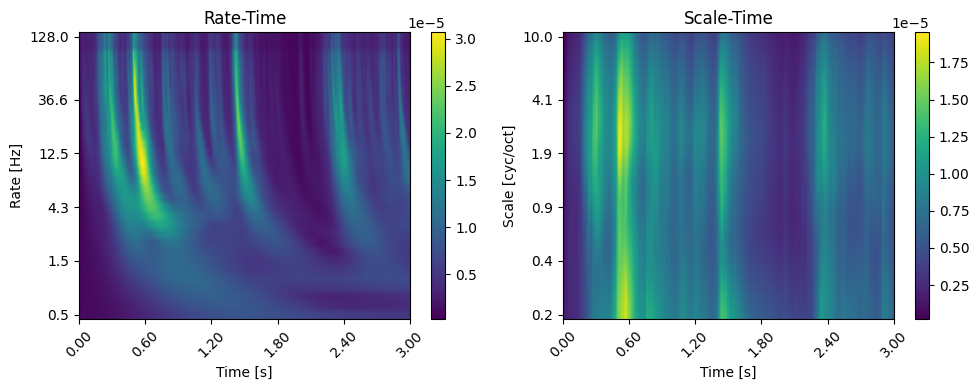

In [6]:
# projections that preserve temporal information
plot_cr_temporal(cr, rates, scales, time_points_audiogram)

## **Alternative configurations**
This section will cover the role of the following key parameters and how to adjust them beyond the defaults:
- `spectral_margin` / `temporal_margin`
- `bandpass`
- `rates` and `scales`

> **Note on resolution:** Rather than using the default resolution of 32 rates x 32 scales, **from this point onwards, examples will be computed at a reduced resolution of 16 rates x 16 scales** to save on memory usage. This is sufficient to illustrate the desired behavior.

---
### **Temporal and spectral margins**
The output array of `aud2cor` has dimensions `(num_scales, num_rates * 2, N + 2 * dN, M + 2 * dM)`. `num_rates` is multiplied by two to account for both upwards and downwards directions. `dM` and `dN` are the margins applied symmetrically to the time and frequency axis, controlled by the parameters `spectral_margin` and `temporal_margin`.

##### **Theoretical background**
In the main loop of aud2cor, essentially a 2D wavelet transform is performed, where the signal is convolved with a wavelet, first along the temporal and then along the log-frequency axis. It is the filter-generating functions that supply this wavelet (more detail on these in later sections).

A convolution in this context evaluates "at this position, how similar is the signal to this wavelet?". Because a wavelet is not a single point, it can extend beyond the edges of the signal, which is why zero-padding is used to handle those edges.

The result of convolving a wavelet with these padding zeroes is generally of little use, except when the original signal must be reconstructed later. The padding can also be useful to avoid edge artifacts or to ensure all relevant information is included. However, the larger the margins, the longer the computation time. **Unless explicitly necessary for your use case, it is recommended to keep the margins at zero (default) to avoid adding unnecessary computational costs.**

##### **Usage**
`spectral_margin` and `temporal_margin` control the temporal and spectral margins and must be a real number between 0 and 1. These values determine the margin index used to extract the relevant values from the wavelet transform. The margin is applied symmetrically to either side of the main spectral content.

The margin index (`dM` or `dN`) is calculated according to

$$dM = \left \lfloor{\frac{M}{2} \times \textrm{spectral margin}}\right \rfloor $$


(likewise for `N, temporal_margin`). The maximum 'fullness' of the margin is roughly half the axis length. For example, given 20 time points, setting `temporal_margin = 1` yields a margin index `dN` of 10. Given 21 time points, `dN` is also 10, due to the `floor` operation.

##### **Example**
Below, the effect of adding a spectral margin is demonstrated. The temporal margin is left unchanged since the effects would not be visible on the plot due to time-averaging, but the result would be similar, just along a different axis.



In [7]:
half_rates = 2 ** np.linspace(np.log2(0.5), np.log2(128), 16)
half_scales = 2 ** np.linspace(np.log2(1/5), np.log2(10), 16)

In [8]:
cr_spectral_margin = aud2cor(audiogram, rates=half_rates, scales=half_scales, spectral_margin=1)
print(f"Cortical representation shape, with spectral margin: {cr_spectral_margin.shape}")

cr_temporal_margin = aud2cor(audiogram, rates=half_rates, scales=half_scales, temporal_margin=1)
print(f"Cortical representation shape, with temporal margin: {cr_temporal_margin.shape}")

cr_default = aud2cor(audiogram, rates=half_rates, scales=half_scales)
print(f"Cortical representation shape, without margins: {cr_default.shape}")


Cortical representation shape, with spectral margin: (16, 32, 750, 256)
Cortical representation shape, with temporal margin: (16, 32, 1500, 128)
Cortical representation shape, without margins: (16, 32, 750, 128)


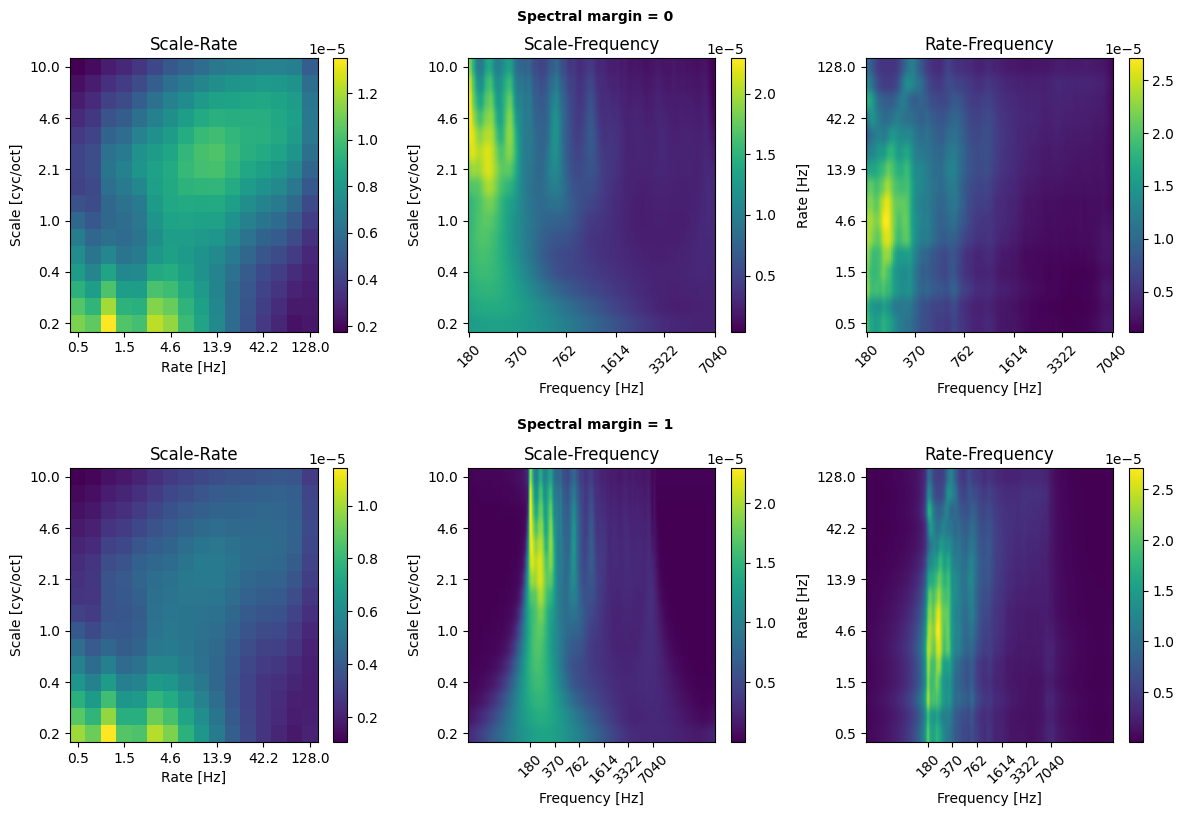

In [9]:
fig, axs_grid = plt.subplots(2, 3, figsize=(12, 8))

plot_cr_projection(cr_default, half_rates, scales=half_scales, frequencies=frequencies_audiogram, axes=axs_grid[0])

plot_cr_projection(cr_spectral_margin, half_rates, scales=half_scales, frequencies=frequencies_audiogram, axes=axs_grid[1])

fig.text(0.5, 1, 'Spectral margin = 0', ha='center',  fontweight='bold')

fig.text(0.5, 0.49, 'Spectral margin = 1', ha='center', fontweight='bold')
plt.tight_layout()
plt.subplots_adjust(hspace=0.5)

plt.show()

### **Rates and scales**
- The **rate** vector describes the temporal modulation rates used to construct the temporal filters (how fast a signal changes in time)
- The **scale** vector describes the spectral modulation rates used to construct the spectral filters (how fast the signal changes across frequency)

These concepts are discussed in more detail in `Tutorial 3`.

---
### **Bandpass indicator**
The `bandpass` parameter controls the passbands of the filters produced by `gen_cort` and `gen_corf`. It is an integer flag (must be `0` or `1`). `True`/`False` are not accepted because the value is used directly in arithmetic when building the filter arguments.
- if `bandpass = 1`, only bandpass filters are generated.
- if `bandpass = 0`, a **lowpass** filter is generated for the first rate and scale, a **highpass** filter for the last rate and scale, and bandpass filters for all intermediate values.

This is a global property: it affects *both* filter-generating functions at once. The shapes of the individual low/band/highpass filters are shown in later sections.

The figure below shows how this choice changes the corticogram.

Both views are shown for each setting from a single `aud2cor` call per bandpass value: the time-averaged projections (`plot_cr_projection`) and the time-resolved rate-time / scale-time views (`plot_cr_temporal`).

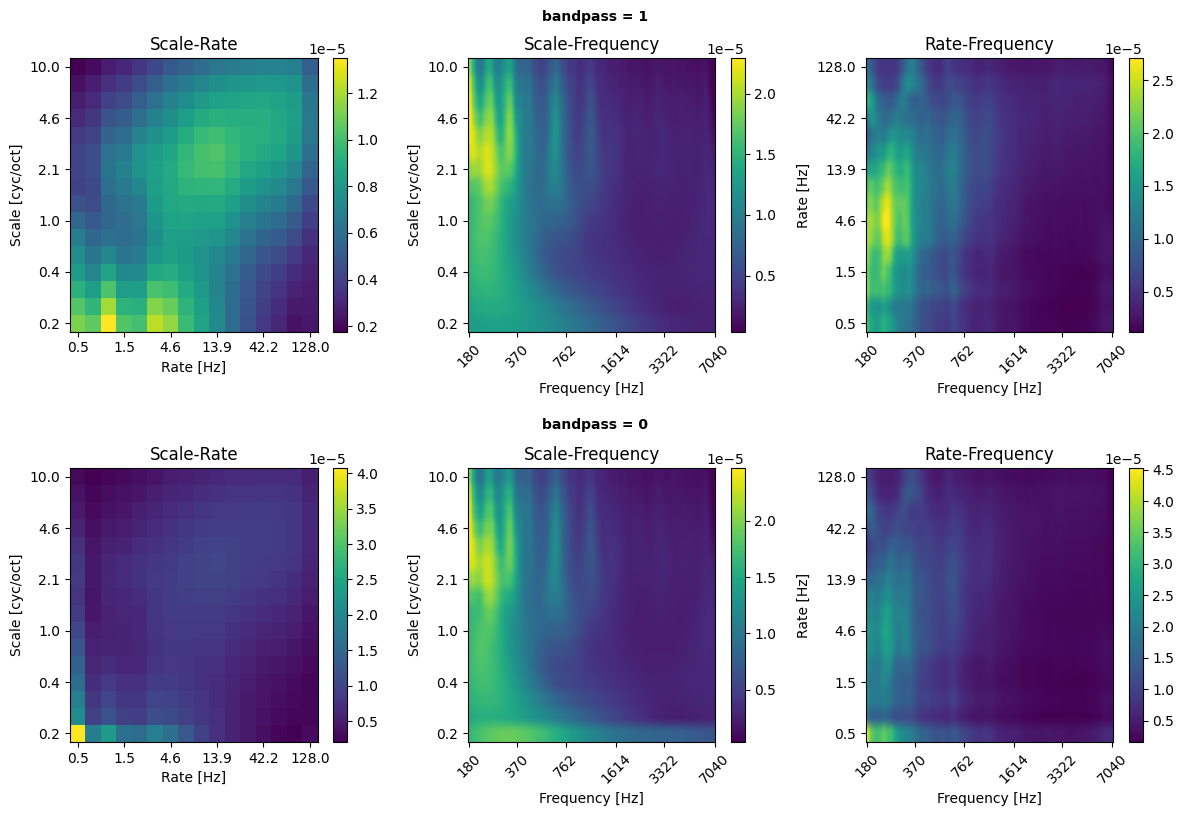

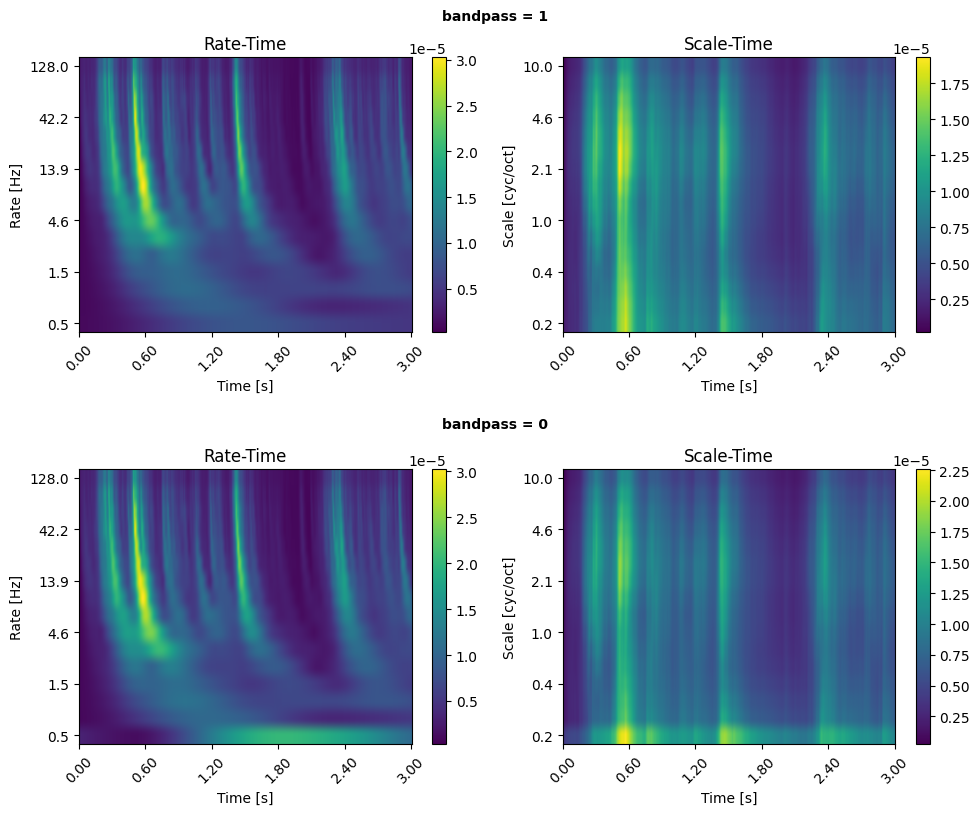

In [10]:

fig_proj, axs_proj = plt.subplots(2, 3, figsize=(12, 8))
fig_temp, axs_temp = plt.subplots(2, 2, figsize=(10, 8))

for row, bp in enumerate([1, 0]):
    cr_case = aud2cor(audiogram, bandpass=bp, rates=half_rates, scales=half_scales)
    plot_cr_projection(cr_case, half_rates, scales=half_scales, frequencies=frequencies_audiogram, axes=axs_proj[row])
    plot_cr_temporal(cr_case, half_rates, scales=half_scales, time_points=time_points_audiogram, axes=axs_temp[row])
    del cr_case # make sure only one cr is held in memory at a time

for fig in (fig_proj, fig_temp):
    fig.text(0.5, 1.0, 'bandpass = 1', ha='center', fontweight='bold')
    fig.text(0.5, 0.49, 'bandpass = 0', ha='center', fontweight='bold')
    fig.tight_layout()
    fig.subplots_adjust(hspace=0.5)
plt.show()

## **Exploring the filter bank**

This section visualises the actual frequency responses that `gen_cort` and `gen_corf` produce and how these are affected by their parameters.

In [11]:
# Parameter setup for the filter-bank plots (reduced 16-resolution, as above)
N, M = audiogram.shape  # (time frames, frequency channels)
# FFT padding
N_pad = int(2 ** np.ceil(np.log2(N)))
M_pad = int(2 ** np.ceil(np.log2(M)))

fps = 1000 / 4  # frames per second, with the default frame_length of 4 ms
channels_per_oct = 20 if M == 95 else 24
num_rates, num_scales = len(half_rates), len(half_scales)

### **Plotting the frequency response**
The shape of the different filters is shown below for some example rates and scales. A few important notes:
- If `bp = 0` it is *always* the first index of the rate/scale that produces the lowpass filter and the last index that
    produces the highpass filter.
- The plots for temporal filters have different resolutions depending on what rate they are tuned to. This is an artifact
    from the choice of FFT bin relative to the bandwidth (which is proportional to the rate). It does not affect filter behavior.

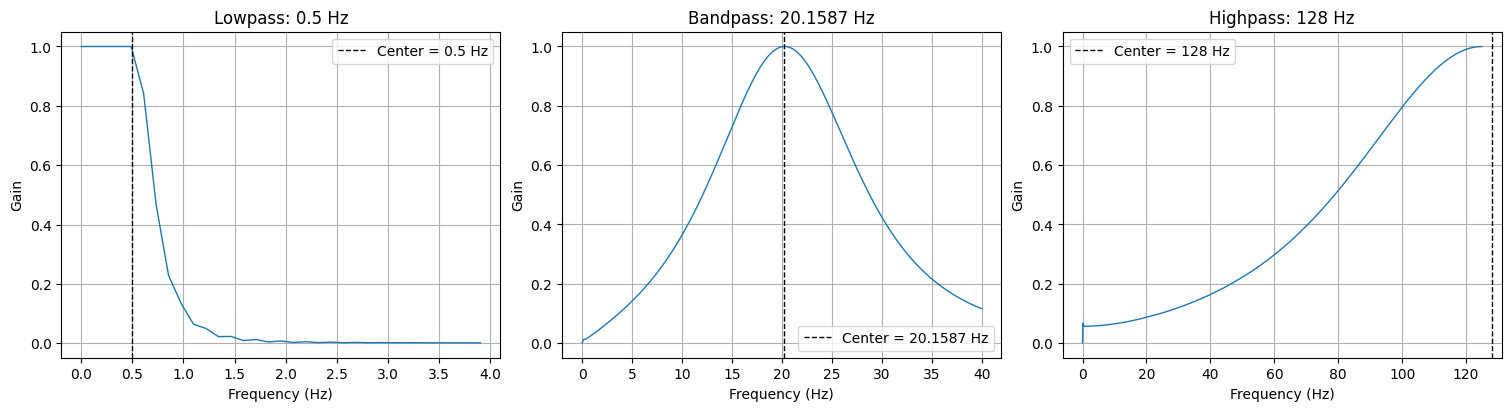

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
indexes_to_plot = [0, 10, num_rates-1]

# NOTE that the frequency axis values change for better visibility and are not uniform across subplots
for ax, rdx in zip(axes, indexes_to_plot):
    bp = 0
    H = gen_cort(half_rates[rdx], N_pad, fps, [rdx + 1 + bp, num_rates + bp * 2])

    _title = f"Bandpass: {half_rates[rdx]:g} Hz"
    _max_freq = 40
    if bp == 0:
        if rdx == 0:
            _title = f"Lowpass: {half_rates[rdx]:g} Hz"
            _max_freq = 4
        elif rdx == num_rates-1:
            _title = f"Highpass: {half_rates[rdx]:g} Hz"
            _max_freq = None

    plot_tempfilt_response(H, fps, center=half_rates[rdx], max_freq=_max_freq, title=_title, ax=ax)

plt.show()

The frequency responses of the spectral filters are shown below. Note that `bp = 0` is set here so that all filter shapes can be seen, although the default is `bp = 1` (all bandpass).

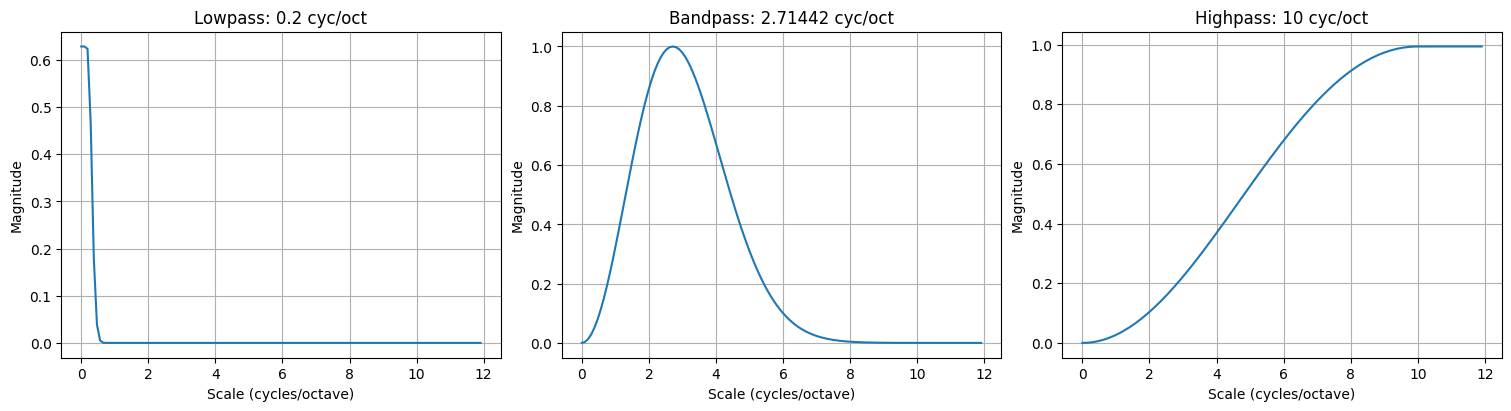

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
scales_to_plot = [half_scales[0], half_scales[10], half_scales[-1]]  # or whichever scales you want

for ax, scale in zip(axes, scales_to_plot):
    sdx = np.argmin(np.abs(half_scales - scale))
    bp = 0
    H = gen_corf(half_scales[sdx], M_pad, channels_per_oct,
                 PASS=[sdx + 1 + bp, num_scales + bp * 2])

    _title = f"Bandpass: {half_scales[sdx]:g} cyc/oct"
    if bp == 0:
        if sdx == 0:
            _title = f"Lowpass: {half_scales[sdx]:g} cyc/oct"
        elif sdx == num_scales-1:
            _title = f"Highpass: {half_scales[sdx]:g} cyc/oct"

    plot_spectfilt_response(
        H,
        channels_per_oct,
        title=_title,
        ax=ax
    )

plt.show()

### **Choosing the spectral filter shape (`func_type`)**

Two functions can be used to derive the spectral transfer function in `gen_corf`:
- A **Gabor** function
    $$ e^{-C (x-1)^2} + e^{-C (x+1)^2} $$

- A **Gaussian** function (the negative second derivative of a Gaussian)
    $$x^2 e^{(1-x^2)}$$

where $C$ is a constant and $x$ denotes the octave offset (channels per 0.5 cycles).

This is selected through the `func_type` argument, which takes the string `'gabor'` or `'gaussian'` (default `'gaussian'`). Below, an example is given for a bandpass filter using each, for the same scale, to illustrate the difference in the resulting filter's shape.

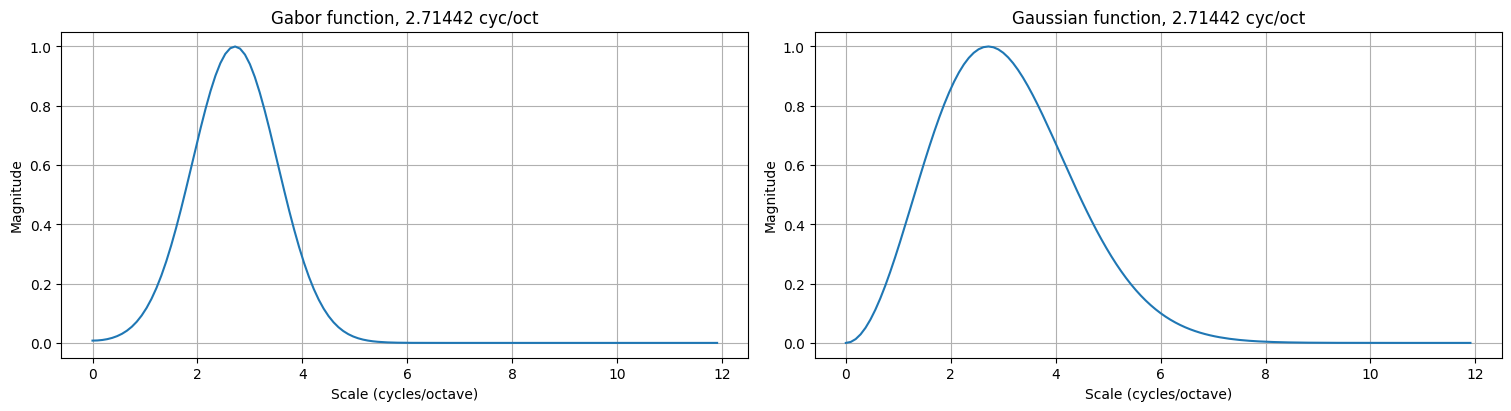

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4), constrained_layout=True)
func_options = ['gabor', 'gaussian']
for ax, func in zip(axes, func_options):
    sdx = 10 # arbitrarily chosen index
    H = gen_corf(half_scales[sdx], M_pad, channels_per_oct, func_type=func)

    _title = f"{func.capitalize()} function, {half_scales[sdx]:g} cyc/oct"

    plot_spectfilt_response(
        H,
        channels_per_oct,
        title=_title,
        ax=ax
    )

plt.show()

# References
[1] Chi, Taishih & Ru, Powen & Shamma, Shihab (2005),
        "Multiresolution spectrotemporal analysis of complex sounds",
        The Journal of the Acoustical Society of America, 118, 887-906, 
        10.1121/1.1945807